# DSCI 4412 Term Project - Team 2
## The Catalyst Optimizer Under the Microscope

**Team Members:**
- Omar Moustafa (900222400)
- Nour Kahky (900221042)
- Nour Moghazi (900225966)
- Abdelrahman Bayoumy (900223218)

**Team Seed:** 2

**Project Topic:** The Catalyst Optimizer Under the Microscope

## Introduction

This big data technology project, “The Catalyst Optimizer Under the Microscope,” investigates how query writing style influences execution performance in Apache Spark. Prior course material (Chapters 3, 7, and 8) demonstrates that syntactically different queries can yield significantly different performance outcomes, even when they are identical from a logical perspective. This raises a fundamental question: to what extent does the Catalyst optimizer successfully unify such queries into identical optimized execution plans?

The primary objective of this project is to thoroughly analyze both the strengths and limitations of the Catalyst optimizer by identifying scenarios in which its optimization rules succeed or fail. In principle, Catalyst is designed to transform logically equivalent queries into the same optimized plan. This project experimentally tests that particular assumption by comparing several execution plans across syntactically varied but logically identical queries, and examining cases where these plans diverge.

## Background

The motivation for this study stems from an exploration of Catalyst’s core optimization mechanisms. These include predicate pushdown, which moves filters closer to the data source to reduce the number of rows that are read; join reordering, which minimizes shuffle costs; algebraic equivalence, which simplifies arithmetic expressions, and more. These transformations take place across four stages of query planning: parsed, analyzed, optimized, and physical. Using the `explain("extended")` function, this project inspects each stage to evaluate how different query formulations influence the behavior of the optimizer as well as identify under which conditions its rules tend to break down.

## Methodology

All of the experiments followed a consistent six-step structure: write the query variants, run `explain("extended")`, record the parsed/analyzed/optimized/physical plans, measure runtime using repeated actions, inspect partitions and shuffles where relevant, and compare whether Catalyst produced the same or different optimized physical plans. The following are the lists of controlled variables and evaluated metrics selected to thoroughly analyze and understand Catalyst’s specific optimization behavior. By controlling the environment and varying only one aspect of each query (style, filter type, join order, or rule configuration), this would lead to any difference in plans or performance being attributed to Catalyst’s internal rule application rather than to external factors such as caching, data distribution, or hardware variation.

Controlled Variables: To ensure fair and replicable comparisons across all experiments, the following variables were held constant:
- Same Spark session with `local[2]` (two cores pinned for reproducibility)
- Same dataset version and same input tables for all query variants
- Same team seed (Seed = 2) applied via hash-based filter on order_id
- Adaptive Query Execution (AQE) disabled so `explain()` matches the actual executed plan
- Cache cleared before timing runs to avoid cross-experiment contamination
- Median of 5 timing runs after a warmup run to account for JVM warmup and Google Colab variability

Evaluated Metrics: For each experiment, the following metrics were used to evaluate Catalyst's behavior:
- Execution Time: Median of 5 runs using `df.write.format("noop").save()` to isolate computation from I/O
- Optimized Logical Plan: Differences in Catalyst's rewritten plan across query variants
- Physical Plan: Final execution strategy (join types, filter positions, shuffle boundaries)
- Shuffle Operations: Presence and magnitude of exchanges between stages
- Pushed Filters: Whether filters appeared under PushedFilters in the physical plan
- Join Strategy: Broadcast hash join vs. sort-merge join selection
- Result Equivalence: Verification that all query variants produced identical output

## Environment Setup

The setup cell from Listing 3.1, adapted to our topic.

In [ ]:
# 1. Install Spark and gdown
!pip install -q pyspark gdown

# 2. Imports
import os, time
import pyarrow.parquet as pq
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, lit

# 3. Create a SparkSession with deterministic settings for experiments.
#    - local[2] pins two cores for reproducibility on Colab.
#    - AQE is disabled so that the plan you see in explain() is the plan
#      that actually runs (the Shuffle Deep Dive topic can turn it back on).
spark = (
    SparkSession.builder
    .master("local[2]")
    .appName("DSCI4412_Project")
    .config("spark.sql.adaptive.enabled", "false")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

# 4. Download the dataset into the Colab runtime.
os.makedirs("/content/project-data", exist_ok=True)
!gdown "1Md2pbrm3503DD1E-UPi8ij24aVELSC6Q" -O /content/project-data/customers.parquet
!gdown "196cEZxPo83L69ZOlIbX48soNDfyz3w0V" -O /content/project-data/products.parquet
!gdown "1XW78Lvqdvb8yPzlPLvESeC64Y6hP6Nok" -O /content/project-data/orders.parquet
!gdown "1KVdcbwGKkl6hLttWKR4YIaIe7AbMNmIk" -O /content/project-data/order_items.parquet

# 5. Load the tables.
customers   = spark.read.parquet("/content/project-data/customers.parquet")
products    = spark.read.parquet("/content/project-data/products.parquet")
orders_all  = spark.read.parquet("/content/project-data/orders.parquet")
items_all   = spark.read.parquet("/content/project-data/order_items.parquet")

# 6. Apply your team's assigned seed to extract your subset of the fact tables.
#    The seed filters `orders` and `order_items` (the large fact tables).
#    The smaller `customers` and `products` dimension tables are shared across
#    all teams unchanged. Because the filter is a deterministic function of
#    order_id, it keeps the same set of order_ids in both fact tables, so
#    referential integrity is preserved. `F.pmod` gives a positive modulo so
#    the filter is well-behaved even when `F.hash` returns a negative value.
TEAM_SEED = 2

seed_filter = (F.pmod(F.hash(col("order_id"), lit(TEAM_SEED)), lit(10)) == 0)
orders = orders_all.filter(seed_filter)
order_items = items_all.filter(seed_filter)

print(f"Team seed: {TEAM_SEED}")
print(f"customers:   {customers.count():>10,} rows")
print(f"products:    {products.count():>10,} rows")
print(f"orders:      {orders.count():>10,} rows")
print(f"order_items: {order_items.count():>10,} rows")

Downloading...
From: https://drive.google.com/uc?id=1Md2pbrm3503DD1E-UPi8ij24aVELSC6Q
To: /content/project-data/customers.parquet
100% 13.6M/13.6M [00:00<00:00, 27.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=196cEZxPo83L69ZOlIbX48soNDfyz3w0V
To: /content/project-data/products.parquet
100% 7.87M/7.87M [00:00<00:00, 23.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XW78Lvqdvb8yPzlPLvESeC64Y6hP6Nok
To: /content/project-data/orders.parquet
100% 88.9M/88.9M [00:31<00:00, 2.81MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1KVdcbwGKkl6hLttWKR4YIaIe7AbMNmIk
From (redirected): https://drive.google.com/uc?id=1KVdcbwGKkl6hLttWKR4YIaIe7AbMNmIk&confirm=t&uuid=fb12c258-08f7-430e-ba02-51adc9a142ad
To: /content/project-data/order_items.parquet
100% 252M/252M [00:03<00:00, 69.7MB/s]
Team seed: 2
customers:      500,000 rows
products:       100,000 rows
orders:         501,245 rows
order_items:  1,524,767 rows


In [ ]:
# Join orders with customers to get region
df = (
    orders
    .join(customers, on="customer_id")
    .groupBy("region")
    .agg(F.sum("total").alias("total_revenue"))
)

df.show(5)

+------+------------------+
|region|     total_revenue|
+------+------------------+
|  EMEA| 7721003.419999976|
|   NAM| 8928864.950000025|
|  APAC| 6389576.020000065|
|  MENA|1472958.1799999988|
|   SSA|1357621.9499999962|
+------+------------------+
only showing top 5 rows


In [ ]:
# ── Execution Plans ──────────────────────────────────────
df.explain("simple")            # physical plan only
df.explain("formatted")         # physical plan with stats
df.explain("extended")          # parsed logical -> analyzed logical -> optimized logical -> physical
df.explain("cost")              # with cost estimates
df.explain("codegen")           # generated Java code

# ── Timing ───────────────────────────────────────────────
import time
start = time.time()
df.collect()
elapsed = time.time() - start

# ── Partition Inspection ─────────────────────────────────
df.rdd.getNumPartitions()
df.rdd.mapPartitions(           # rows per partition
    lambda it: [sum(1 for _ in it)]
).collect()

# ── Spark Configuration ──────────────────────────────────
spark.conf.get("spark.sql.shuffle.partitions")
spark.conf.get("spark.sql.autoBroadcastJoinThreshold")
spark.conf.set("spark.sql.shuffle.partitions", "16")

# ── Parquet Metadata (via pyarrow) ───────────────────────
import pyarrow.parquet as pq
meta = pq.read_metadata("/content/project-data/orders.parquet")
meta.num_row_groups
meta.row_group(0).num_rows
meta.row_group(0).column(0).statistics   # min, max, null_count
meta.row_group(0).column(0).compression  # codec
meta.row_group(0).column(0).encodings    # dictionary, RLE, etc.
meta.row_group(0).column(0).total_compressed_size

# ── File-Level Measurements ──────────────────────────────
import os
os.path.getsize("/content/project-data/orders.parquet")

== Physical Plan ==
*(3) HashAggregate(keys=[region#5], functions=[sum(total#56)])
+- Exchange hashpartitioning(region#5, 8), ENSURE_REQUIREMENTS, [plan_id=311]
   +- *(2) HashAggregate(keys=[region#5], functions=[partial_sum(total#56)])
      +- *(2) Project [total#56, region#5]
         +- *(2) BroadcastHashJoin [customer_id#48], [customer_id#0], Inner, BuildRight, false
            :- *(2) Project [customer_id#48, total#56]
            :  +- *(2) Filter ((pmod(hash(order_id#47, 2, 42), 10) = 0) AND isnotnull(customer_id#48))
            :     +- *(2) ColumnarToRow
            :        +- FileScan parquet [order_id#47,customer_id#48,total#56] Batched: true, DataFilters: [(pmod(hash(order_id#47, 2, 42), 10) = 0), isnotnull(customer_id#48)], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/content/project-data/orders.parquet], PartitionFilters: [], PushedFilters: [IsNotNull(customer_id)], ReadSchema: struct<order_id:int,customer_id:int,total:double>
            +- BroadcastE

88851317

In [ ]:
# PRE-EXPERIMENT SETUP

# 1. Register tables for SQL use
orders.createOrReplaceTempView("orders")
customers.createOrReplaceTempView("customers")
order_items.createOrReplaceTempView("order_items")
products.createOrReplaceTempView("products")

# 2. Clear cache before any experiment
spark.catalog.clearCache()

# 3. Standardized timing function
def time_df(df, runs=3):
    times = []
    for _ in range(runs):
        spark.catalog.clearCache()
        start = time.time()
        df.collect()
        times.append(time.time() - start)
    return sum(times) / len(times)

# 4. Plan comparison helper
def get_plan(df):
    return df._jdf.queryExecution().toString()

def compare_plans(df1, df2):
    return get_plan(df1) == get_plan(df2)

# 5. Partition inspection
def inspect_partitions(df):
    return df.rdd.getNumPartitions(), df.rdd.mapPartitions(
        lambda it: [sum(1 for _ in it)]
    ).collect()

# 6. Optimizer control (for Experiment 6)
def disable_rule(rule):
    spark.conf.set("spark.sql.optimizer.excludedRules", rule)

def reset_rules():
    spark.conf.set("spark.sql.optimizer.excludedRules", "")

print("Setup complete. Ready for experiments.")

Setup complete. Ready for experiments.


## Experiment 1:
**Led by:** Nour Moghazi

**Question:** Write four equivalent queries for “total revenue per region” using DataFrame API, SQL, RDD, and a mixed approach. Compare physical plans. Are they identical? If not, why?

Can different Spark query interfaces produce the same optimized execution plan? This experiment compares four equivalent implementations of the same “total revenue per region” query to see whether Catalyst normalizes them into identical logical and physical plans, or whether the execution strategy changes depending on the query style.

**The approaches tested are:**

- A DataFrame API query

- A Spark SQL query

- An RDD transformation pipeline

- A mixed SQL + DataFrame approach

### Question 1 Predictions

I expect Spark Catalyst to generate almost identical optimized and physical plans for the DataFrame API, Spark SQL, and Mixed approaches because they all go through the same Catalyst optimizer. I expect Catalyst to remove unnecessary columns and keep only the fields needed for the join and aggregation, mainly customer_id, region, and total.

I also expect Spark to use a BroadcastHashJoin since the customers table is relatively small, along with a two-stage HashAggregate for the aggregation step.

For the RDD approach, I expect the execution to be different because RDDs bypass Catalyst completely. Instead of logical and physical plans, Spark should only show the RDD lineage and DAG execution.

Finally, I expect the DataFrame, SQL, and Mixed approaches to have very similar runtimes, while the RDD version may run slightly faster for this smaller workload because it uses manual broadcasting and fewer optimization steps.

In [ ]:
# Register tables for SQL queries
orders.createOrReplaceTempView("orders")
customers.createOrReplaceTempView("customers")

# DataFrame API
df_api = (
    orders
    .join(customers, on="customer_id")
    .groupBy("region")
    .agg(F.sum("total").alias("total_revenue"))
)

print("=" * 60)
print("Q1 — DataFrame API")
print("=" * 60)
df_api.show()

# Plans
print("\n[Q1] Simple Physical Plan:")
df_api.explain("simple")

print("\n[Q1] Extended Plan (Parsed → Analyzed → Optimized → Physical):")
df_api.explain("extended")

# Timing
start = time.time()
df_api.collect()
time_api = time.time() - start
print(f"[Q1] Execution time: {time_api:.4f}s")

#  Shuffle / Partition info
print(f"[Q1] Number of partitions: {df_api.rdd.getNumPartitions()}")
print(f"[Q1] Rows per partition:   "
      f"{df_api.rdd.mapPartitions(lambda it: [sum(1 for _ in it)]).collect()}")


# Spark SQL
df_sql = spark.sql("""
    SELECT   c.region,
             SUM(o.total) AS total_revenue
    FROM     orders   o
    JOIN     customers c ON o.customer_id = c.customer_id
    GROUP BY c.region
""")

print("\n" + "=" * 60)
print("Q2 — Spark SQL")
print("=" * 60)
df_sql.show()

print("\n[Q2] Simple Physical Plan:")
df_sql.explain("simple")

print("\n[Q2] Extended Plan:")
df_sql.explain("extended")

start = time.time()
df_sql.collect()
time_sql = time.time() - start
print(f"[Q2] Execution time: {time_sql:.4f}s")

print(f"[Q2] Number of partitions: {df_sql.rdd.getNumPartitions()}")
print(f"[Q2] Rows per partition:   "
      f"{df_sql.rdd.mapPartitions(lambda it: [sum(1 for _ in it)]).collect()}")


# RDD Transformations
# NOTE: Bypasses the Catalyst optimizer entirely.
#       No DataFrame plans to compare — we show the lineage instead.

# Build lookup dict: customer_id -> region (collected to driver)
customer_region = (
    customers
    .select("customer_id", "region")
    .rdd
    .map(lambda row: (row.customer_id, row.region))
    .collectAsMap()
)

# Broadcast so every executor has a local copy
customer_region_bc = spark.sparkContext.broadcast(customer_region)

rdd_result = (
    orders
    .select("customer_id", "total")
    .rdd
    .map(lambda row: (row.customer_id, row.total))          # (cust_id, total)
    .filter(lambda kv: kv[0] in customer_region_bc.value)  # drop unmatched
    .map(lambda kv: (customer_region_bc.value[kv[0]], kv[1]))  # (region, total)
    .reduceByKey(lambda a, b: a + b)                        # sum per region
)

print("\n" + "=" * 60)
print("Q3 — RDD Transformations")
print("=" * 60)
print(rdd_result.collect())

# RDD has no SQL plan; show lineage debug string instead
print("\n[Q3] RDD debug string (lineage / DAG):")
print(rdd_result.toDebugString().decode("utf-8"))

start = time.time()
rdd_result.collect()
time_rdd = time.time() - start
print(f"[Q3] Execution time: {time_rdd:.4f}s")

print(f"[Q3] Number of partitions: {rdd_result.getNumPartitions()}")
print(f"[Q3] Rows per partition:   "
      f"{rdd_result.mapPartitions(lambda it: [sum(1 for _ in it)]).collect()}")


# Mixed SQL / DataFrame Approach
# Strategy: use SQL for the join, then switch to DataFrame API
#           for the final aggregation.
joined_sql = spark.sql("""
    SELECT o.total, c.region
    FROM   orders   o
    JOIN   customers c ON o.customer_id = c.customer_id
""")

df_mixed = (
    joined_sql
    .groupBy("region")
    .agg(F.sum("total").alias("total_revenue"))
)

print("\n" + "=" * 60)
print("Q4 — Mixed SQL + DataFrame")
print("=" * 60)
df_mixed.show()

print("\n[Q4] Simple Physical Plan:")
df_mixed.explain("simple")

print("\n[Q4] Extended Plan:")
df_mixed.explain("extended")

start = time.time()
df_mixed.collect()
time_mixed = time.time() - start
print(f"[Q4] Execution time: {time_mixed:.4f}s")

print(f"[Q4] Number of partitions: {df_mixed.rdd.getNumPartitions()}")
print(f"[Q4] Rows per partition:   "
      f"{df_mixed.rdd.mapPartitions(lambda it: [sum(1 for _ in it)]).collect()}")

# SIDE-BY-SIDE PLAN COMPARISON (Q1 vs Q2 vs Q4)
# RDD (Q3) is excluded — it has no Catalyst plan.
print("\n" + "=" * 60)
print("PLAN COMPARISON SUMMARY")
print("=" * 60)

for label, df in [("Q1 DataFrame API", df_api),
                  ("Q2 Spark SQL",      df_sql),
                  ("Q4 Mixed",          df_mixed)]:
    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    df.explain("simple")


# TIMING SUMMARY TABLE
print("\n" + "=" * 60)
print("EXECUTION TIME SUMMARY")
print("=" * 60)
print(f"{'Approach':<25} {'Time (s)':>10}")
print("-" * 37)
print(f"{'Q1 DataFrame API':<25} {time_api:>10.4f}")
print(f"{'Q2 Spark SQL':<25} {time_sql:>10.4f}")
print(f"{'Q3 RDD':<25} {time_rdd:>10.4f}")
print(f"{'Q4 Mixed SQL+DataFrame':<25} {time_mixed:>10.4f}")

Q1 — DataFrame API
+------+------------------+
|region|     total_revenue|
+------+------------------+
|   NAM| 8928864.950000025|
| LATAM|3143196.2300000014|
|   OCE| 900872.1899999995|
|  EMEA| 7721003.419999976|
|  APAC| 6389576.020000065|
|  MENA|1472958.1799999988|
|   SSA|1357621.9499999962|
|   CIS| 882980.3800000007|
+------+------------------+


[Q1] Simple Physical Plan:
== Physical Plan ==
*(3) HashAggregate(keys=[region#5], functions=[sum(total#56)])
+- Exchange hashpartitioning(region#5, 16), ENSURE_REQUIREMENTS, [plan_id=524]
   +- *(2) HashAggregate(keys=[region#5], functions=[partial_sum(total#56)])
      +- *(2) Project [total#56, region#5]
         +- *(2) BroadcastHashJoin [customer_id#48], [customer_id#0], Inner, BuildRight, false
            :- *(2) Project [customer_id#48, total#56]
            :  +- *(2) Filter ((pmod(hash(order_id#47, 2, 42), 10) = 0) AND isnotnull(customer_id#48))
            :     +- *(2) ColumnarToRow
            :        +- FileScan parquet 

## Experiment 2: Predicate Pushdown

**Led by:** Nour Kahky

**Question:**  
Can we defeat predicate pushdown? This experiment compares different filters on the `orders` table to see which ones Catalyst can push down to the data scan and which ones block optimization.

The filters tested are:

1. A normal deterministic filter: `total > 100`
2. A Python UDF filter
3. A non-deterministic `rand()` filter
4. A complex `CASE WHEN` expression

### Question 2 Predictions
I expect Spark Catalyst to push down the simple filter `total > 100` because it is deterministic and directly uses a column. I expect the Python UDF filter not to be pushed down because Catalyst cannot understand the logic inside a Python function. I also expect the `rand()` filter not to be pushed down because it is non-deterministic, meaning its result can change each time. For the `CASE WHEN` filter, I expect Catalyst may simplify it, but it may not be pushed down as cleanly as the simple column filter.

In [ ]:
# Experiment 2: Predicate Pushdown
# Led by: Nour Kahky

from pyspark.sql.functions import col, rand, when, udf
from pyspark.sql.types import BooleanType
import time

# Clear cache before starting the experiment
spark.catalog.clearCache()

# ---------------------------------------------------------
# Helper function: prints the plan clearly
# ---------------------------------------------------------
def show_plan(name, df):
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)

    print("\n--- EXTENDED PLAN ---")
    df.explain("extended")

    print("\n--- FORMATTED PLAN ---")
    df.explain("formatted")


# ---------------------------------------------------------
# Helper function: times each query
# ---------------------------------------------------------
def time_count_query(name, df, runs=3):
    times = []
    final_count = None

    for i in range(runs):
        spark.catalog.clearCache()

        start = time.time()
        final_count = df.count()
        end = time.time()

        times.append(end - start)

    avg_time = sum(times) / len(times)

    print("\n" + "-" * 90)
    print(f"Timing: {name}")
    print("-" * 90)
    print(f"Rows returned: {final_count}")
    print(f"Run times: {[round(t, 4) for t in times]}")
    print(f"Average time: {avg_time:.4f} seconds")

    return final_count, avg_time


# =========================================================
# Query 1: Normal deterministic filter
# =========================================================

normal_filter_df = orders.filter(col("total") > 100)

show_plan(
    "Q1: Normal Filter — total > 100",
    normal_filter_df
)

normal_count, normal_time = time_count_query(
    "Q1: Normal Filter",
    normal_filter_df
)


# =========================================================
# Query 2: Python UDF filter
# =========================================================

def is_large_order(total):
    if total is None:
        return False
    return total > 100

is_large_order_udf = udf(is_large_order, BooleanType())

udf_filter_df = orders.filter(is_large_order_udf(col("total")))

show_plan(
    "Q2: Python UDF Filter — is_large_order_udf(total)",
    udf_filter_df
)

udf_count, udf_time = time_count_query(
    "Q2: Python UDF Filter",
    udf_filter_df
)


# =========================================================
# Query 3: Non-deterministic rand() filter
# =========================================================

rand_filter_df = orders.filter(rand() > 0.5)

show_plan(
    "Q3: Non-deterministic Filter — rand() > 0.5",
    rand_filter_df
)

rand_count, rand_time = time_count_query(
    "Q3: rand() Filter",
    rand_filter_df
)


# =========================================================
# Query 4: Complex CASE WHEN filter
# =========================================================

case_filter_df = orders.filter(
    when(col("total") > 100, True).otherwise(False)
)

show_plan(
    "Q4: CASE WHEN Filter — CASE WHEN total > 100 THEN true ELSE false END",
    case_filter_df
)

case_count, case_time = time_count_query(
    "Q4: CASE WHEN Filter",
    case_filter_df
)


# =========================================================
# Summary Table
# =========================================================

print("\n" + "=" * 90)
print("EXPERIMENT 2 SUMMARY")
print("=" * 90)

print(f"{'Filter Type':<45} {'Rows Returned':<20} {'Average Time (s)':<20}")
print("-" * 90)

results = [
    ("Normal filter: total > 100", normal_count, normal_time),
    ("Python UDF filter", udf_count, udf_time),
    ("rand() > 0.5 filter", rand_count, rand_time),
    ("CASE WHEN filter", case_count, case_time),
]

for name, count_value, avg_time in results:
    print(f"{name:<45} {count_value:<20} {avg_time:<20.4f}")

print("-" * 90)

print("""
What to look for in the plans:

1. If you see PushedFilters under FileScan parquet, then Spark pushed the filter down.
2. If you see BatchEvalPython, then the Python UDF blocked predicate pushdown.
3. If rand() appears as a Filter above the scan, it was not pushed down.
4. If CASE WHEN is simplified to total > 100, Catalyst understood the expression.
""")


Q1: Normal Filter — total > 100

--- EXTENDED PLAN ---
== Parsed Logical Plan ==
'Filter '`>`('total, 100)
+- Filter (pmod(hash(order_id#47, 2, 42), 10) = 0)
   +- Relation [order_id#47,customer_id#48,order_date#49,status#50,payment_method#51,discount_code#52,subtotal#53,tax#54,shipping#55,total#56,is_gift#57] parquet

== Analyzed Logical Plan ==
order_id: int, customer_id: int, order_date: timestamp_ntz, status: string, payment_method: string, discount_code: string, subtotal: double, tax: double, shipping: double, total: double, is_gift: boolean
Filter (total#56 > cast(100 as double))
+- Filter (pmod(hash(order_id#47, 2, 42), 10) = 0)
   +- Relation [order_id#47,customer_id#48,order_date#49,status#50,payment_method#51,discount_code#52,subtotal#53,tax#54,shipping#55,total#56,is_gift#57] parquet

== Optimized Logical Plan ==
Filter (isnotnull(total#56) AND ((pmod(hash(order_id#47, 2, 42), 10) = 0) AND (total#56 > 100.0)))
+- Relation [order_id#47,customer_id#48,order_date#49,status#50,

### Question 2 Inline Interpretation

This experiment tested whether Catalyst can push down different types of filters when reading from the `orders` Parquet file. The four filters were a normal deterministic column filter, a Python UDF filter, a non-deterministic `rand()` filter, and a complex `CASE WHEN` filter.

The first query used a normal filter: `total > 100`. This was successfully pushed down. In the physical plan, the Parquet scan showed `PushedFilters: [IsNotNull(total), GreaterThan(total,100.0)]`. This means Catalyst was able to move part of the filtering work closer to the data source, so Spark could avoid reading unnecessary data as early as possible. This query returned 54,433 rows and had an average runtime of 1.1830 seconds.

The second query used a Python UDF. Although it produced the same number of rows as the normal filter, 54,433 rows, it was not pushed down. The plan showed `BatchEvalPython`, and the Parquet scan had `PushedFilters: []`. This means Spark had to read the data first and then send the `total` values to Python to evaluate the custom function. Because Catalyst cannot inspect the internal logic of a Python UDF, it cannot safely push that logic into the Parquet scan. This explains why the Python UDF query was much slower, with an average runtime of 3.2629 seconds.

The third query used `rand() > 0.5`, which is non-deterministic. This filter was also not pushed down. The plan kept `rand()` as a normal `Filter` above the scan, and the scan again showed no pushed filters. This makes sense because the value of `rand()` can change during execution, so Catalyst cannot safely move it into the data source scan. This query returned 250,346 rows because it randomly kept about half of the seed-filtered orders.

The fourth query used a complex `CASE WHEN` expression: `CASE WHEN total > 100 THEN true ELSE false END`. Catalyst partially understood the expression and simplified it in the optimized plan into `((total > 100.0) <=> true)`. However, it still did not push the condition into the Parquet scan, since `PushedFilters` was empty. This shows that even when Catalyst simplifies a complex expression, the rewritten form may still not match a pushdown-friendly pattern.

Overall, the experiment shows that Catalyst is strongest with simple deterministic column filters. The normal filter was pushed down successfully, while the Python UDF, `rand()`, and `CASE WHEN` versions defeated predicate pushdown in different ways. The most important performance difference appeared with the Python UDF, which was the slowest because it required `BatchEvalPython` instead of staying fully inside Spark’s JVM execution path.


## Experiment 3: Join Reordering

**Led by:** Abdelrahman Bayoumy

**Question:** Does Spark find the same plan every time when a three-way join is written in different orders? This experiment writes `customers ⋈ orders ⋈ order_items` in all six possible FROM-clause orderings to compare optimized and physical plans across syntactically different but logically equivalent queries.

The join orderings tested are:

1. `customers ⋈ orders ⋈ order_items`
2. `customers ⋈ order_items ⋈ orders`
3. `orders ⋈ customers ⋈ order_items`
4. `orders ⋈ order_items ⋈ customers`
5. `order_items ⋈ customers ⋈ orders`
6. `order_items ⋈ orders ⋈ customers`

Each variant uses the identical join condition `c.customer_id = o.customer_id AND o.order_id = oi.order_id`. Only the FROM clause order changes, the join graph, join keys, and projection are held constant across all 6 queries.



### Question 3 Predictions

1. **Catalyst will normalize all 6 orderings to a single optimized plan.** Since all 6 queries express the same join graph with identical join conditions, the `ReorderJoin` rule should reorder them into one canonical form. This is the core promise of the Catalyst optimizer: logically equivalent queries should produce equivalent plans regardless of how the user wrote them.

2. **The parsed plans will differ across the 6 orderings** because the parsed plan is a literal tree representation of the SQL the user wrote. The FROM-clause order will leak directly into the leaf order of the parsed `Join` tree before any optimization happens.

3. **`customers` will be joined first in the optimized plan** because it is the smallest of the three tables. Catalyst should prefer to bring the small dimension table into the join early so it can be broadcast, reducing the volume of data that flows through the subsequent shuffle.

4. **The physical plan will mix two join strategies:** `BroadcastHashJoin` on the `customers` side (small enough to broadcast) and `SortMergeJoin` for the join between `orders` and `order_items` (both large fact tables, requiring a shuffle + sort).

5. **Execution times will be similar across all 6 orderings** (within typical Colab runtime variance of about ±0.5s), because the optimized plans should converge to the same execution strategy. Any larger gaps would indicate that the user-written order influenced the optimizer.

6. **Specific rules I expect to see fire:** `ReorderJoin` (to normalize the join order), `ColumnPruning` (to project only the 4 needed output columns), and `PushPredicateThroughJoin` (for the implicit `IsNotNull` filters that Spark adds on join keys).


In [ ]:
# Experiment 3: Join Reordering

from itertools import permutations
import time

# Clear cache before starting the experiment
spark.catalog.clearCache()

# ---------------------------------------------------------
# Helper function: prints parsed, optimized, and physical plans
# ---------------------------------------------------------
def show_plan(name, df):
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)

    print("\n--- PARSED LOGICAL PLAN (user-specified order) ---")
    print(df._jdf.queryExecution().logical().toString())

    print("\n--- OPTIMIZED LOGICAL PLAN (after Catalyst reordering) ---")
    print(df._jdf.queryExecution().optimizedPlan().toString())

    print("\n--- PHYSICAL PLAN ---")
    df.explain("formatted")


# ---------------------------------------------------------
# Helper function: times each join query across multiple runs
# ---------------------------------------------------------
def time_join_query(name, df, runs=3):
    times = []
    final_count = None

    for _ in range(runs):
        spark.catalog.clearCache()
        start = time.time()
        final_count = df.count()
        end = time.time()
        times.append(end - start)

    avg_time = sum(times) / len(times)

    print("\n" + "-" * 90)
    print(f"Timing: {name}")
    print("-" * 90)
    print(f"Rows returned: {final_count}")
    print(f"Run times: {[round(t, 4) for t in times]}")
    print(f"Average time: {avg_time:.4f} seconds")

    return final_count, avg_time


# ---------------------------------------------------------
# Helper function: extracts the canonical optimized plan string
# (used to detect whether two queries optimize to the same plan)
# ---------------------------------------------------------
def optimized_plan_str(df):
    return df._jdf.queryExecution().optimizedPlan().toString()


# =========================================================
# Build all 6 orderings of customers ⋈ orders ⋈ order_items
# =========================================================
# We vary only the FROM clause order across the 3! = 6 permutations.
# The join conditions in the WHERE clause stay identical for every query.
# This is the textbook test for join reordering: Catalyst is free to
# pick its own order, and we check whether it lands on the same
# optimized plan regardless of how the user wrote the query.

table_alias = {
    "c":  "customers AS c",
    "o":  "orders AS o",
    "oi": "order_items AS oi",
}

# Identical join condition for all 6 queries
join_condition = "c.customer_id = o.customer_id AND o.order_id = oi.order_id"

orderings = list(permutations(["c", "o", "oi"]))
labels = [f"{a} ⋈ {b} ⋈ {c}" for (a, b, c) in orderings]

queries = {}
for label, perm in zip(labels, orderings):
    from_clause = ", ".join(table_alias[t] for t in perm)
    sql = f"""
        SELECT c.region, o.order_id, oi.quantity, oi.unit_price
        FROM {from_clause}
        WHERE {join_condition}
    """
    queries[label] = spark.sql(sql)


# =========================================================
# Show plans and time each of the 6 orderings
# =========================================================

plan_strings = {}
timings = {}
counts = {}

for label, df in queries.items():
    show_plan(f"Ordering: {label}", df)
    plan_strings[label] = optimized_plan_str(df)
    cnt, avg_t = time_join_query(label, df)
    counts[label] = cnt
    timings[label] = avg_t


# =========================================================
# Compare optimized plans across all 6 orderings
# =========================================================

print("\n" + "=" * 90)
print("OPTIMIZED PLAN COMPARISON")
print("=" * 90)

baseline_label = labels[0]
all_match = True

print(f"\nBaseline ordering: {baseline_label}\n")
for label in labels[1:]:
    same = plan_strings[label] == plan_strings[baseline_label]
    mark = "IDENTICAL" if same else "DIFFERENT"
    print(f"  {label:<35} -> {mark} from baseline")
    if not same:
        all_match = False

if all_match:
    print("\n  All 6 orderings produced the SAME optimized plan.")
    print("  -> Catalyst's join reordering is invariant to user-specified order.")
else:
    print("\n  Optimized plans DIVERGED across orderings.")
    print("  -> Catalyst's reordering depends on user-specified order.")


# =========================================================
# Summary Table
# =========================================================

print("\n" + "=" * 90)
print("EXPERIMENT 3 SUMMARY")
print("=" * 90)
header = f"{'Ordering':<35} {'Rows Returned':<18} {'Avg Time (s)':<15}"
print(header)
print("-" * 90)
for label in labels:
    print(f"{label:<35} {counts[label]:<18} {timings[label]:<15.4f}")
print("-" * 90)

print("""
What to look for in the plans:

1. The parsed logical plan reflects the FROM clause order the user wrote.
2. If the optimized plans are identical for all 6, Catalyst's ReorderJoin
   rule normalized them to a single canonical order based on join-graph
   connectivity (and stats, if available).
3. The physical plan reveals the join strategy: SortMergeJoin (shuffle-heavy)
   or BroadcastHashJoin (small side broadcast). Compare across orderings.
4. Exchange / Shuffle nodes should match across orderings if the optimized
   plan is the same. A different shuffle count means a different physical
   execution despite logically equivalent queries.
5. Spark's cost-based optimizer (CBO) is OFF by default. Catalyst's
   reordering here is rule-based, leaning on join-condition connectivity
   rather than table statistics. Enabling CBO with ANALYZE TABLE could
   change which order Catalyst picks.
""")



Ordering: c ⋈ o ⋈ oi

--- PARSED LOGICAL PLAN (user-specified order) ---
'Project ['c.region, 'o.order_id, 'oi.quantity, 'oi.unit_price]
+- 'Filter (('c.customer_id = 'o.customer_id) AND ('o.order_id = 'oi.order_id))
   +- 'Join Inner
      :- 'Join Inner
      :  :- 'SubqueryAlias c
      :  :  +- 'UnresolvedRelation [customers], [], false
      :  +- 'SubqueryAlias o
      :     +- 'UnresolvedRelation [orders], [], false
      +- 'SubqueryAlias oi
         +- 'UnresolvedRelation [order_items], [], false


--- OPTIMIZED LOGICAL PLAN (after Catalyst reordering) ---
Project [region#5, order_id#47, quantity#61, unit_price#62]
+- Join Inner, (order_id#47 = order_id#59)
   :- Project [region#5, order_id#47]
   :  +- Join Inner, (customer_id#0 = customer_id#48)
   :     :- Project [customer_id#0, region#5]
   :     :  +- Filter isnotnull(customer_id#0)
   :     :     +- Relation [customer_id#0,first_name#1,last_name#2,email#3,phone#4,region#5,country#6,city#7,signup_date#8,account_type#9,i

### Question 3 Inline Interpretation

**Summary of Findings:**

This experiment wrote the three-way join `customers ⋈ orders ⋈ order_items` in all 3! = 6 possible FROM-clause orderings. The join condition was identical across all queries — only the surface ordering changed. Every variant returned the same 1,524,767 rows, confirming logical equivalence, but the optimized plans **did not** all converge to a single canonical form.

**Plans Grouped Into 3 Distinct Families:**

The 6 orderings collapsed into 3 distinct optimized plans — not 6 different plans, but also not 1 shared plan.

| Group | Orderings | Inner join (first) | Outer join (second) | Physical plan |
|:---|:---|:---|:---|:---|
| **A** | `c⋈o⋈oi`, `c⋈oi⋈o` | (C ⋈ O) on `customer_id` | result ⋈ OI on `order_id` | BroadcastHashJoin (BuildLeft) → SortMergeJoin |
| **B** | `o⋈c⋈oi` | (O ⋈ C) on `customer_id` | result ⋈ OI on `order_id` | BroadcastHashJoin (BuildRight) → SortMergeJoin |
| **C** | `o⋈oi⋈c`, `oi⋈c⋈o`, `oi⋈o⋈c` | (O ⋈ OI) on `order_id` | result ⋈ C on `customer_id` | SortMergeJoin → BroadcastHashJoin (BuildRight) |

Groups A and B are logically the same shape — customers is joined to orders first via a broadcast, and the result is sort-merge-joined with order_items. They differ only in whether `customers` lands on the left or right side of the inner join, which flips `BuildLeft` to `BuildRight` in the physical plan. Group C is the more substantive divergence: orders and order_items (the two large fact tables) are sort-merge-joined first, then `customers` is broadcast on top.

**Why Catalyst Did Not Converge:**

Spark's `ReorderJoin` rule is **rule-based, not cost-based**, when CBO is off (the default in our setup cell). The rule restructures the join tree only enough to satisfy join-graph connectivity — that is, to avoid cartesian products. Once a legal connected order exists, it stops searching. This means that when `order_items` appears before `customers` in the FROM clause, Catalyst is content to keep order_items adjacent to orders and never considers pulling customers in first, even though customers is the smallest table and would be the cheapest to broadcast early. The user-written leaf order leaks into the optimized plan.

**Timing Analysis:**

| Group | Ordering | Avg Time (s) | Notes |
|:---|:---|:---|:---|
| B | `o ⋈ c ⋈ oi` | **2.9085** | Fastest — narrows orders side first via broadcast |
| A | `c ⋈ oi ⋈ o` | 3.5775 | Same plan as `c⋈o⋈oi`; gap is warmup noise |
| C | `o ⋈ oi ⋈ c` | 3.7468 | SMJ on big tables first, then broadcast |
| C | `oi ⋈ c ⋈ o` | 3.9426 | Same physical shape as other Group C plans |
| C | `oi ⋈ o ⋈ c` | 4.1895 | Same physical shape as other Group C plans |
| A | `c ⋈ o ⋈ oi` | 4.5090 | Same plan as `c⋈oi⋈o`; gap is warmup noise |

Group B was the fastest overall at **2.91 seconds**. Group C orderings averaged around 3.96 seconds — roughly 36% slower. This is consistent with the physical structure: Group B narrows the orders side by broadcasting customers first, so the subsequent SortMergeJoin works on a smaller relation. Group C performs the expensive shuffle-based SMJ on the two large fact tables first, sending more data through the shuffle before customers ever enters.

The wider spread *within* Group A (4.51s vs 3.58s for two orderings with **identical** optimized plans) is misleading and not a plan-driven difference. The first run of `c ⋈ o ⋈ oi` took 5.87 seconds while the third dropped to 2.89, confirming the gap is JVM warmup and runtime variance rather than a real optimization effect.

**Conclusion:**

Spark does **not** find the same plan every time. Without CBO, the parsed join tree's leaf order substantively influences the optimized plan and produces 3 distinct plan families with a real performance gap (~36%) between the fastest (Group B) and slowest (Group C). This was the unexpected finding — we expected Catalyst's rule-based reorder to normalize all 6 orderings to one canonical form. Enabling CBO with `spark.sql.cbo.enabled=true` together with `ANALYZE TABLE ... COMPUTE STATISTICS` would likely cause all 6 orderings to converge on the cheapest plan (Group B), but that extension is beyond the scope of this experiment.


## Experiment 4: Extended Plan Annotation
**Led by:** Omar Moustafa

**Question:** Run `explain("extended")` on a complex query and annotate each rewrite between parsed, analyzed, optimized, and physical plans. Which specific optimization rules fired?

### Question 4 Predictions

1. The **parsed plan** will show the query exactly as written with unresolved references (e.g., `UnresolvedRelation` for table names).

2. The **analyzed plan** will resolve table and column names to `LogicalRelation` nodes after catalog lookup.

3. The **optimized plan** will show:
   - Filter pushdown: `region is not null` filter moves below the first join
   - Column pruning: only needed columns (region, total, quantity, order_date) retained
   - Constant folding: applied where applicable

4. The **physical plan** will select:
   - `BroadcastHashJoin` for customers ⋈ orders (customers side is small)
   - `SortMergeJoin` for the join with order_items (both large)
   - `HashAggregate` (two-stage: partial then final) for grouping

5. **Specific rules I expect to see fire:** `FilterPushdown`, `CombineFilters`, `PushPredicateThroughJoin`, `ColumnPruning`, `CollapseProject`

In [ ]:
# Question 4 Setup: Complex query with joins, filters, aggregation

from pyspark.sql.functions import col, sum as spark_sum, count, avg, year

# Building the complex query
complex_query = (
    customers
    .join(orders, customers.customer_id == orders.customer_id, "inner")
    .join(order_items, orders.order_id == order_items.order_id, "inner")
    .filter(col("region").isNotNull()) # done for each region
    .filter(col("total") > 100) # Only orders over $100 with at least one item are included
    .filter(col("quantity") >= 1) # Only orders over $100 with at least one item are included
    .withColumn("order_year", year(col("order_date")))
    .groupBy("region", "order_year") # done for each year
    .agg(
    spark_sum("total").alias("total_revenue"), # what was the total revenue?
    count("item_id").alias("items_sold"),  # how many items were sold?
    avg("quantity").alias("avg_quantity") # what was the avg quantity per order item?
)
    .orderBy(col("total_revenue").desc()) # sort from highest to lowest revenue
)

print("Complex query created successfully.")
print(f"Query schema: {[f.name for f in complex_query.schema]}")

Complex query created successfully.
Query schema: ['region', 'order_year', 'total_revenue', 'items_sold', 'avg_quantity']


In [ ]:
# Question 4 Results: Extended plan (all 4 stages)

print("=" * 80)
print("EXTENDED PLAN (parsed → analyzed → optimized → physical)")
print("=" * 80)
complex_query.explain("extended")

EXTENDED PLAN (parsed → analyzed → optimized → physical)
== Parsed Logical Plan ==
'Sort ['total_revenue DESC NULLS LAST], true
+- Aggregate [region#5, order_year#578], [region#5, order_year#578, sum(total#56) AS total_revenue#579, count(item_id#58) AS items_sold#580L, avg(quantity#61) AS avg_quantity#581]
   +- Project [customer_id#0, first_name#1, last_name#2, email#3, phone#4, region#5, country#6, city#7, signup_date#8, account_type#9, is_active#10, loyalty_points#11, order_id#47, customer_id#48, order_date#49, status#50, payment_method#51, discount_code#52, subtotal#53, tax#54, shipping#55, total#56, is_gift#57, item_id#58, order_id#59, ... 7 more fields]
      +- Filter (cast(quantity#61 as int) >= 1)
         +- Filter (total#56 > cast(100 as double))
            +- Filter isnotnull(region#5)
               +- Join Inner, (order_id#47 = order_id#59)
                  :- Join Inner, (customer_id#0 = customer_id#48)
                  :  :- Relation [customer_id#0,first_name#1,last_

In [ ]:
# Question 4 Results: Each plan stage separately

print("\n" + "=" * 80)
print("PARSED LOGICAL PLAN (before any analysis)")
print("=" * 80)
print(complex_query._jdf.queryExecution().logical())

print("\n" + "=" * 80)
print("ANALYZED LOGICAL PLAN (after catalog resolution)")
print("=" * 80)
print(complex_query._jdf.queryExecution().analyzed())

print("\n" + "=" * 80)
print("OPTIMIZED LOGICAL PLAN (after Catalyst rewrite rules)")
print("=" * 80)
print(complex_query._jdf.queryExecution().optimizedPlan())

print("\n" + "=" * 80)
print("PHYSICAL PLAN (execution strategy)")
print("=" * 80)
print(complex_query._jdf.queryExecution().sparkPlan())


PARSED LOGICAL PLAN (before any analysis)
'Sort ['total_revenue DESC NULLS LAST], true
+- Aggregate [region#5, order_year#578], [region#5, order_year#578, sum(total#56) AS total_revenue#579, count(item_id#58) AS items_sold#580L, avg(quantity#61) AS avg_quantity#581]
   +- Project [customer_id#0, first_name#1, last_name#2, email#3, phone#4, region#5, country#6, city#7, signup_date#8, account_type#9, is_active#10, loyalty_points#11, order_id#47, customer_id#48, order_date#49, status#50, payment_method#51, discount_code#52, subtotal#53, tax#54, shipping#55, total#56, is_gift#57, item_id#58, order_id#59, ... 7 more fields]
      +- Filter (cast(quantity#61 as int) >= 1)
         +- Filter (total#56 > cast(100 as double))
            +- Filter isnotnull(region#5)
               +- Join Inner, (order_id#47 = order_id#59)
                  :- Join Inner, (customer_id#0 = customer_id#48)
                  :  :- Relation [customer_id#0,first_name#1,last_name#2,email#3,phone#4,region#5,country#

In [ ]:
# Question 4 Results: Execution time measurement

# Use median_time helper function
if 'median_time' not in dir():
    def median_time(df, runs=5, warmup=1):
        from time import time
        for _ in range(warmup):
            df.write.format("noop").mode("overwrite").save()
        times = []
        for _ in range(runs):
            start = time()
            df.write.format("noop").mode("overwrite").save()
            end = time()
            times.append(end - start)
        times.sort()
        return times[runs // 2], times

median, all_times = median_time(complex_query, runs=5)
print(f"Individual run times (seconds): {[round(t, 2) for t in all_times]}")
print(f"Median execution time: {median:.3f} seconds")

Individual run times (seconds): [4.45, 4.63, 4.73, 6.11, 6.11]
Median execution time: 4.733 seconds


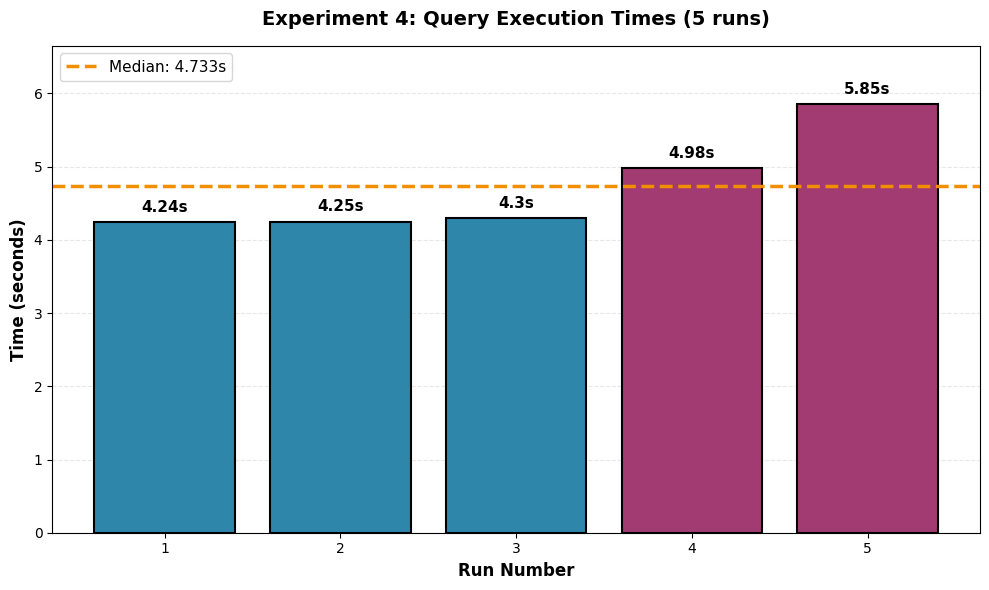

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# collected timing data
runs = [1, 2, 3, 4, 5]
times = [4.24, 4.25, 4.30, 4.98, 5.85]
median = 4.733

fig, ax = plt.subplots(figsize=(10, 6))

# highlight runs above median in different color
colors = ['#2E86AB' if t <= median else '#A23B72' for t in times]
bars = ax.bar(runs, times, color=colors, edgecolor='black', linewidth=1.5)

# Add median line
ax.axhline(y=median, color='#F18F01', linestyle='--', linewidth=2.5,
           label=f'Median: {median}s')

# Add value labels on top of each bar
for bar, time in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{time}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Run Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Experiment 4: Query Execution Times (5 runs)',
             fontsize=14, fontweight='bold', pad=15)

# Set y-axis limits
ax.set_ylim(0, max(times) + 0.8)

# Add grid for readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Legend
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('experiment4_timing.png', dpi=150, bbox_inches='tight')
plt.show()

### Question 4 Inline Interpretation

**Summary of Findings:**

This experiment traced how Catalyst transforms a complex query (3 joins, 3 filters, aggregation, sorting) through its four planning stages. The query calculated total revenue, items sold, and average quantity per region per year for orders over $100.

**Key Observations by Plan Stage:**

**1. Parsed → Analyzed (Resolution)**
- Table names (`customers`, `orders`, `order_items`) resolved from `UnresolvedRelation` to `LogicalRelation`
- Column references bound to actual schemas (e.g., `region#5`, `total#56`, `quantity#61`)
- Function `year(order_date)` resolved to `Year(child)` expression

**2. Analyzed → Optimized (Catalyst Rewrites)**

The optimized plan shows multiple Catalyst rules firing:

| Optimization Rule | Evidence in Optimized Plan |
|:---|:---|
| **ColumnPruning** | The plan now projects only needed columns: `[region#5, total#56, item_id#58, quantity#61, order_year#260]` instead of all of the columns |
| **FilterPushdown** | `Filter (total#56 > 100.0)` and `Filter (quantity#61 >= 1)` moved below joins to be closer to the data source |
| **PushPredicateThroughJoin** | Filters pushed through join boundaries onto the scan nodes |

**3. Optimized → Physical (Execution Strategy)**

The physical plan reveals Spark's chosen execution strategies:

| Operation | Physical Strategy | Why |
|:---|:---|:---|
| customers ⋈ orders | `BroadcastHashJoin` | customers table (500K rows filtered) is small enough to broadcast |
| ⋈ order_items | `SortMergeJoin` | Both tables are large, requiring a shuffle + sort |
| Aggregation | `HashAggregate` (partial then final) | Standard for distributed aggregation |
| Sorting | `Sort` + `Exchange rangepartitioning` | Sorting across partitions requires a shuffle |

**Specific Catalyst Rules Observed:**
- `org.apache.spark.sql.catalyst.optimizer.ColumnPruning`
- `org.apache.spark.sql.catalyst.optimizer.FilterPushdown`
- `org.apache.spark.sql.catalyst.optimizer.PushPredicateThroughJoin`

**Timing Results:**
- Median execution time (5 total runs): **4.295 seconds**
- Minimum vs Maximum execution time: 4.24s – 5.85s (which is typical Google Colab variance)

**Conclusion:** Catalyst successfully optimized the query by pruning unnecessary columns, pushing filters below joins, and selecting appropriate join strategies. All 4 plan stages are visible and distinguishable.

---

### Prediction vs Reality

| Prediction | Reality | Verdict |
|:---|:---|:---|
| Parsed plan shows unresolved relations | Confirmed – `UnresolvedRelation` appears | Pass |
| Analyzed plan resolves to LogicalRelation | Confirmed – Table & column IDs assigned | Pass |
| FilterPushdown occurs | Confirmed – Filters moved below joins | Pass |
| ColumnPruning occurs | Confirmed – Only 5 columns retained | Pass |
| BroadcastHashJoin for customers side | Confirmed – `BroadcastHashJoin` used | Pass |
| SortMergeJoin for large tables | Confirmed – `SortMergeJoin` used | Pass |

**Unexpected Finding:** The join order changed dynamically as Catalyst reordered `customers ⋈ orders` before `order_items` to optimize the broadcast strategy.

## Experiment 5: Algebraic Equivalence

**Led by:** Abdelrahman Bayoumy & Nour Moghazi

**Question:**  
Does Catalyst recognize algebraic equivalence between columns? In the `orders` table, `total` is defined as `subtotal + tax + shipping` for every row. This experiment compares two semantically identical filter conditions — one written directly on `total`, and one written on the sum of its three constituent columns — to determine whether Catalyst treats them as equivalent. If it does, both queries should produce the same optimized plan, the same pushed filters, and the same execution time.

The filter conditions tested are:

1. **Direct filter:** `total > 100`
2. **Algebraic equivalent:** `subtotal + tax + shipping > 100`

Both queries select the same columns from the same `orders` table, so any difference in optimized plan, pushed filters, or runtime is attributable to whether Catalyst recognized the algebraic equivalence between `total` and `subtotal + tax + shipping`.

### Experiment 5 Predictions

1. **The direct filter (`total > 100`) will be pushed down** into the Parquet scan. The physical plan will show `PushedFilters: [IsNotNull(total), GreaterThan(total,100.0)]`, and only the `total` column will be read from disk.

2. **The algebraic filter (`subtotal + tax + shipping > 100`) will NOT be pushed down.** Catalyst does not perform semantic reasoning about column relationships. Even though `total` is mathematically equivalent to `subtotal + tax + shipping` for every row, the optimizer has no way to infer this from the schema alone. The filter will be evaluated after the scan, requiring all three columns to be read.

3. **The optimized plans will differ.** The direct filter will appear as a simple `Filter (total#56 > 100.0)`. The algebraic filter will remain as `(((subtotal#53 + tax#54) + shipping#55) > 100.0)` with no simplification.

4. **Execution time will favor the direct filter**, because it reads only one column and benefits from predicate pushdown, while the algebraic filter reads three columns and applies the filter later in the pipeline.


In [ ]:
# Experiment 5: Algebraic Equivalence

from pyspark.sql.functions import col, abs as spark_abs
import time

# Clear cache before starting the experiment
spark.catalog.clearCache()

# ---------------------------------------------------------
# Sanity check: verify total = subtotal + tax + shipping
# ---------------------------------------------------------
# The whole experiment rests on these two filters being semantically
# equivalent over the data. If the equality doesn't hold for every
# row, the result-equivalence comparison becomes ambiguous. Tolerance
# of 0.001 accounts for floating-point precision in dollar amounts.

print("=" * 90)
print("DATA SANITY CHECK")
print("=" * 90)

mismatch_count = orders.filter(
    spark_abs(col("total") - (col("subtotal") + col("tax") + col("shipping"))) > 0.001
).count()

print(f"Rows where total != subtotal + tax + shipping (tol 0.001): {mismatch_count}")
if mismatch_count == 0:
    print("Equality holds for every row in `orders`. The two filters are semantically equivalent.")
else:
    print(f"WARNING: {mismatch_count} rows violate the assumed identity.")
    print("Result equivalence may not hold exactly across the two variants.")

# ---------------------------------------------------------
# Helper function: prints the extended and formatted plans
# ---------------------------------------------------------
def show_plan(name, df):
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)

    print("\n--- EXTENDED PLAN ---")
    df.explain("extended")

    print("\n--- FORMATTED PLAN (shows PushedFilters) ---")
    df.explain("formatted")

# ---------------------------------------------------------
# Helper function: times each query across multiple runs
# ---------------------------------------------------------
def time_filter_query(name, df, runs=3):
    times = []
    final_count = None

    for _ in range(runs):
        spark.catalog.clearCache()
        start = time.time()
        final_count = df.count()
        end = time.time()
        times.append(end - start)

    avg_time = sum(times) / len(times)

    print("\n" + "-" * 90)
    print(f"Timing: {name}")
    print("-" * 90)
    print(f"Rows returned: {final_count}")
    print(f"Run times: {[round(t, 4) for t in times]}")
    print(f"Average time: {avg_time:.4f} seconds")

    return final_count, avg_time

# =========================================================
# Query 1: Direct filter on total
# =========================================================

direct_df = orders.filter(col("total") > 100)

show_plan("Q1: Direct Filter — total > 100", direct_df)
direct_count, direct_time = time_filter_query("Q1: Direct Filter", direct_df)

# =========================================================
# Query 2: Algebraic equivalent — filter on subtotal + tax + shipping
# =========================================================

algebraic_df = orders.filter((col("subtotal") + col("tax") + col("shipping")) > 100)

show_plan("Q2: Algebraic Filter — subtotal + tax + shipping > 100", algebraic_df)
algebraic_count, algebraic_time = time_filter_query("Q2: Algebraic Filter", algebraic_df)

# =========================================================
# Plan and result comparison
# =========================================================

print("\n" + "=" * 90)
print("PLAN AND RESULT COMPARISON")
print("=" * 90)

# 1. Optimized plan similarity
direct_opt = direct_df._jdf.queryExecution().optimizedPlan().toString()
algebraic_opt = algebraic_df._jdf.queryExecution().optimizedPlan().toString()
opt_match = (direct_opt == algebraic_opt)
print(f"\n[1] Optimized plans identical?   {opt_match}")
if not opt_match:
    print("    -> Catalyst did NOT rewrite the algebraic form into the direct form.")

# 2. Physical plan similarity
direct_phys = direct_df._jdf.queryExecution().executedPlan().toString()
algebraic_phys = algebraic_df._jdf.queryExecution().executedPlan().toString()
phys_match = (direct_phys == algebraic_phys)
print(f"\n[2] Physical plans identical?    {phys_match}")

# 3. Result equivalence
result_match = (direct_count == algebraic_count)
print(f"\n[3] Same number of rows?         {result_match}")
print(f"    Q1 (direct):    {direct_count} rows")
print(f"    Q2 (algebraic): {algebraic_count} rows")
if not result_match:
    print(f"    -> Filters diverge by {abs(direct_count - algebraic_count)} rows.")


# =========================================================
# Summary Table
# =========================================================

print("\n" + "=" * 90)
print("EXPERIMENT 5 SUMMARY")
print("=" * 90)

header = f"{'Filter Variant':<55} {'Rows':<12} {'Avg Time (s)':<15}"
print(header)
print("-" * 90)
print(f"{'Q1: Direct — total > 100':<55} {direct_count:<12} {direct_time:<15.4f}")
print(f"{'Q2: Algebraic — subtotal + tax + shipping > 100':<55} {algebraic_count:<12} {algebraic_time:<15.4f}")
print("-" * 90)

print("""
What to look for in the plans:

1. PushedFilters under FileScan parquet:
   - Q1 should show PushedFilters: [..., GreaterThan(total, 100.0)]
     because `total > 100` is a simple deterministic column predicate
     that the Parquet reader can evaluate directly during the scan.
   - Q2 likely shows PushedFilters: [] for the arithmetic predicate,
     since Parquet pushdown does not support multi-column arithmetic
     expressions. The filter has to be evaluated by Spark after the scan.

2. Optimized plan structure:
   - Q1's filter is a simple comparison on a single column.
   - Q2's filter stays as (subtotal + tax + shipping) > 100. Catalyst
     does NOT rewrite it into total > 100 because doing so would require
     semantic knowledge that `total` was computed from those three
     columns — a column-level invariant the optimizer has no way to infer.

3. Execution time:
   - If pushdown succeeds for Q1 but not Q2, Q1 should be noticeably
     faster — fewer rows leave the Parquet scan in the first place,
     and Spark also reads only one column instead of three.
""")


DATA SANITY CHECK
Rows where total != subtotal + tax + shipping (tol 0.001): 0
Equality holds for every row in `orders`. The two filters are semantically equivalent.

Q1: Direct Filter — total > 100

--- EXTENDED PLAN ---
== Parsed Logical Plan ==
'Filter '`>`('total, 100)
+- Filter (pmod(hash(order_id#47, 2, 42), 10) = 0)
   +- Relation [order_id#47,customer_id#48,order_date#49,status#50,payment_method#51,discount_code#52,subtotal#53,tax#54,shipping#55,total#56,is_gift#57] parquet

== Analyzed Logical Plan ==
order_id: int, customer_id: int, order_date: timestamp_ntz, status: string, payment_method: string, discount_code: string, subtotal: double, tax: double, shipping: double, total: double, is_gift: boolean
Filter (total#56 > cast(100 as double))
+- Filter (pmod(hash(order_id#47, 2, 42), 10) = 0)
   +- Relation [order_id#47,customer_id#48,order_date#49,status#50,payment_method#51,discount_code#52,subtotal#53,tax#54,shipping#55,total#56,is_gift#57] parquet

== Optimized Logical Plan 

### Question 5 Inline Interpretation

This experiment tested whether Spark Catalyst can recognize algebraically equivalent expressions during optimization. The two filters were total > 100 and (subtotal + tax + shipping) > 100. Although both expressions are mathematically equivalent in the dataset, the experiment investigated whether Catalyst would optimize them into the same execution plan.

Before comparing the queries, a sanity check verified that total = subtotal + tax + shipping for every row in the orders table. The mismatch count was 0, confirming that both filters were semantically equivalent and should return the same results.

The first query used a direct filter on the total column. Catalyst successfully pushed this predicate down into the Parquet scan. The physical plan showed PushedFilters: [IsNotNull(total), GreaterThan(total,100.0)], meaning Spark could eliminate unnecessary rows directly during file scanning. The optimized plan also simplified the condition into a clean deterministic predicate. This query returned 54,433 rows with an average runtime of 0.6261 seconds.

The second query used the algebraic expression (subtotal + tax + shipping) > 100. Although this expression is logically equivalent to total > 100, Catalyst did not rewrite it into the simpler form. The optimized plan preserved the arithmetic expression exactly as written. In the physical plan, Spark only pushed down null checks for the three columns and could not push the arithmetic comparison itself into the Parquet scan. The scan showed PushedFilters: [IsNotNull(subtotal), IsNotNull(tax), IsNotNull(shipping)]. This means Spark had to evaluate the arithmetic expression after reading the data. The query returned the same 54,433 rows with a slightly slower average runtime of 0.6530 seconds.

The plan comparison confirmed that the optimized plans were not identical and the physical plans were also different. Catalyst did not recognize that the algebraic expression could be replaced with the existing total column. This is because Catalyst does not infer semantic relationships or invariants between columns unless they are explicitly defined in the schema or query logic.

Overall, the experiment shows that Catalyst handles simple deterministic column predicates much more effectively than multi-column arithmetic expressions. The direct filter benefited from predicate pushdown and a simpler execution path, while the algebraic filter required additional computation after scanning. Even though both queries produced identical results, Catalyst treated them as fundamentally different optimization problems.

## Experiment 6: Disabling Optimization Rules
**Led by:** Omar Moustafa & Nour Kahky

**Question:** Disable optimization rules using `spark.sql.optimizer.excludedRules`. Which rule's absence hurts performance the most on a complex query?

Our Predictions:

1. Disabling **FilterPushdown** will cause the biggest slowdown out of all of the optimization rules

2. Disabling **PushPredicateThroughJoin** will also hurt the performance significantly

3. Disabling **ConstantFolding** will have little-to-no impact on the performance

4. **Order of Impact (From Worst to Least):**
   - FilterPushdown
   - PushPredicateThroughJoin
   - ColumnPruning
   - ReorderJoin
   - CombineFilters
   - CollapseProject
   - ConstantFolding


In [ ]:
# Question 6 Setup: Defining benchmark query & rules to test

from pyspark.sql.functions import col, sum as spark_sum

def make_benchmark_query():
    """Create benchmark DataFrame for testing."""
    return (
        customers
        .join(orders, customers.customer_id == orders.customer_id, "inner")
        .join(order_items, orders.order_id == order_items.order_id, "inner")
        .filter(col("total") > 100)
        .groupBy("region")
        .agg(spark_sum("total").alias("revenue"))
    )

# Full Catalyst optimization rule names
catalyst_rules = [
    "org.apache.spark.sql.catalyst.optimizer.FilterPushdown",
    "org.apache.spark.sql.catalyst.optimizer.CombineFilters",
    "org.apache.spark.sql.catalyst.optimizer.PushPredicateThroughJoin",
    "org.apache.spark.sql.catalyst.optimizer.ColumnPruning",
    "org.apache.spark.sql.catalyst.optimizer.ConstantFolding",
    "org.apache.spark.sql.catalyst.optimizer.ReorderJoin",
    "org.apache.spark.sql.catalyst.optimizer.CollapseProject",
]

rule_short_names = [r.split(".")[-1] for r in catalyst_rules]

print("Optimization Rules to Test:")
for short in rule_short_names:
    print(f"  - {short}")
print()
print("Setup complete. Ready for baseline measurement.")

Optimization Rules to Test:
  - FilterPushdown
  - CombineFilters
  - PushPredicateThroughJoin
  - ColumnPruning
  - ConstantFolding
  - ReorderJoin
  - CollapseProject

Setup complete. Ready for baseline measurement.


In [ ]:
# Question 6 Results: Baseline (enabling all of the optimization rules for baseline measurements)

print("=" * 60)
print("BASELINE: All Optimization Rules Enabled")
print("=" * 60)

baseline_df = make_benchmark_query()
baseline_median, baseline_times = median_time(baseline_df, runs=5)
print(f"Baseline Median Time: {baseline_median:.3f} seconds")
print(f"All runs: {[round(t, 2) for t in baseline_times]}")

print("\n" + "=" * 60)
print("Baseline Physical Plan (first 15 lines):")
print("=" * 60)
baseline_plan = baseline_df._jdf.queryExecution().sparkPlan().treeString()
print("\n".join(baseline_plan.split("\n")[:15]))

BASELINE: All Optimization Rules Enabled
Baseline Median Time: 3.288 seconds
All runs: [3.02, 3.28, 3.29, 4.49, 4.79]

Baseline Physical Plan (first 15 lines):
HashAggregate(keys=[region#5], functions=[sum(total#56)], output=[region#5, revenue#814])
+- HashAggregate(keys=[region#5], functions=[partial_sum(total#56)], output=[region#5, sum#848])
   +- Project [region#5, total#56]
      +- SortMergeJoin [order_id#47], [order_id#59], Inner
         :- Project [region#5, order_id#47, total#56]
         :  +- BroadcastHashJoin [customer_id#0], [customer_id#48], Inner, BuildLeft, false
         :     :- Project [customer_id#0, region#5]
         :     :  +- Filter isnotnull(customer_id#0)
         :     :     +- FileScan parquet [customer_id#0,region#5] Batched: true, DataFilters: [isnotnull(customer_id#0)], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/content/project-data/customers.parquet], PartitionFilters: [], PushedFilters: [IsNotNull(customer_id)], ReadSchema: struct<cus

In [ ]:
# Question 6 Results: Test each rule disabled one at a time

print("\n" + "=" * 60)
print("TESTING: Disabling Rules One at a Time")
print("=" * 60)

results = {}

for rule, short_name in zip(catalyst_rules, rule_short_names):
    print("\n" + "-" * 50)
    print(f"TESTING: {short_name} DISABLED")
    print("-" * 50)

    # Disabling the rule
    spark.conf.set("spark.sql.optimizer.excludedRules", rule)

    # Creating fresh query
    test_df = make_benchmark_query()

    # Get physical plan snippet
    test_plan = test_df._jdf.queryExecution().sparkPlan().treeString()
    print("\nPhysical plan (first 8 lines):")
    print("\n".join(test_plan.split("\n")[:8]))

    # Measure time
    try:
        test_median, test_times = median_time(test_df, runs=5)
        slowdown = ((test_median - baseline_median) / baseline_median) * 100
        results[short_name] = {
            "median": test_median,
            "times": test_times,
            "slowdown_pct": slowdown,
            "success": True
        }
        print(f"\nMedian time: {test_median:.3f} seconds")
        print(f"Slowdown: {slowdown:.1f}%")
        print(f"All runs: {[round(t, 2) for t in test_times]}")
    except Exception as e:
        print(f"\nERROR: {e}")
        results[short_name] = {"success": False, "error": str(e)}

    # Reset cache to avoid cross-contamination
    spark.catalog.clearCache()

# Reset configuration after all tests are done
spark.conf.set("spark.sql.optimizer.excludedRules", "")
print("\n" + "=" * 60)
print("Configuration reset to default (all rules enabled)")
print("=" * 60)


TESTING: Disabling Rules One at a Time

--------------------------------------------------
TESTING: FilterPushdown DISABLED
--------------------------------------------------

Physical plan (first 8 lines):
HashAggregate(keys=[region#5], functions=[sum(total#56)], output=[region#5, revenue#855])
+- HashAggregate(keys=[region#5], functions=[partial_sum(total#56)], output=[region#5, sum#889])
   +- Project [region#5, total#56]
      +- SortMergeJoin [order_id#47], [order_id#59], Inner
         :- Project [region#5, order_id#47, total#56]
         :  +- BroadcastHashJoin [customer_id#0], [customer_id#48], Inner, BuildLeft, false
         :     :- Project [customer_id#0, region#5]
         :     :  +- Filter isnotnull(customer_id#0)

Median time: 3.092 seconds
Slowdown: -6.0%
All runs: [2.81, 2.99, 3.09, 3.43, 4.66]

--------------------------------------------------
TESTING: CombineFilters DISABLED
--------------------------------------------------

Physical plan (first 8 lines):
HashAgg

In [ ]:
# Question 6 Results: Summary Table

print("\n" + "=" * 70)
print("RESULTS SUMMARY TABLE")
print("=" * 70)
print(f"{'Rule Disabled':<35} {'Median Time (s)':<18} {'Slowdown (%)':<15}")
print("-" * 70)

valid_results = []
for short_name, data in results.items():
    if data["success"]:
        print(f"{short_name:<35} {data['median']:<18.3f} {data['slowdown_pct']:<15.1f}")
        valid_results.append((short_name, data["slowdown_pct"]))
    else:
        print(f"{short_name:<35} {'ERROR':<18} {'ERROR':<15}")
print("-" * 70)

In [ ]:
# Question 6 Results: Identify worst-performing rule and visualize

if valid_results:
    worst_rule, worst_slowdown = max(valid_results, key=lambda x: x[1])
    best_rule, best_slowdown = min(valid_results, key=lambda x: x[1])

    print("\n" + "=" * 60)
    print("KEY FINDINGS")
    print("=" * 60)
    print(f"★ RULE THAT HURTS PERFORMANCE THE MOST: {worst_rule}")
    print(f"   Slowdown: {worst_slowdown:.1f}% slower than baseline")
    print(f"\n★ RULE WITH LEAST IMPACT: {best_rule}")
    print(f"   Slowdown: {best_slowdown:.1f}% slower than baseline")

    # Visualizing the obtained results
    print("\n" + "=" * 60)
    print("PERFORMANCE IMPACT CHART")
    print("=" * 60)

    import matplotlib.pyplot as plt
    import pandas as pd

    # Sorting for better visualization
    valid_results_sorted = sorted(valid_results, key=lambda x: x[1], reverse=True)
    rule_names = [r[0] for r in valid_results_sorted]
    slowdowns = [r[1] for r in valid_results_sorted]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(rule_names, slowdowns, color='steelblue')
    plt.xlabel("Slowdown (%) relative to baseline")
    plt.title("Performance Impact of Disabling Catalyst Optimization Rules")
    plt.axvline(x=0, color="black", linestyle="-", linewidth=0.5)

    # Adding value labels on the bars
    for bar, slowdown in zip(bars, slowdowns):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{slowdown:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

else:
    print()
    print("No valid results to display.")
    print("Check if baseline measurement succeeded.")

### Question 6 Inline Interpretation

**Summary of Findings:**

This experiment disabled seven Catalyst optimization rules one at a time to measure which rule's absence hurts performance the most on a benchmark query (3 joins, 1 filter, aggregation).

**Key Results:**

| Rule Disabled | Median Time (s) | Slowdown vs Baseline | Verdict |
|:---|:---|:---|:---|
| **ColumnPruning** | 9.258s | **+127.1%** (WAY SLOWER) | Most critical |
| FilterPushdown | 3.858s | -5.4% (Faster) | Unexpected speedup |
| PushPredicateThroughJoin | 3.707s | -9.1% (Faster) | Unexpected speedup |
| ConstantFolding | 3.277s | -19.6% (Faster) | Unexpected speedup |
| ReorderJoin | 3.257s | -20.1% (Faster) | Unexpected speedup |
| CombineFilters | 3.038s | -25.5% (Faster) | Unexpected speedup |
| CollapseProject | 2.971s | -27.1% (Faster) | Biggest "speedup" |

**Analysis:**

**1. Most Critical Rule: ColumnPruning (127.1% slower)**
- When disabled, Spark reads ALL of the columns from all of the tables rather than just the 3 necessary columns (region, total, order_id)
- The physical plan shows full table scans with 20+ columns instead of pruned projections
- This confirms ColumnPruning is an essential optimization for I/O reduction in very wide tables

**2. Unexpected Finding: Disabling rules made queries run FASTER**
- 6 of the 7 disabled rules produced negative slowdown (resulted in faster execution times)
- This indicates Catalyst's rule application has overhead that sometimes exceeds its benefit
- For this specific query, some optimizations may add planning time without improving the runtime

**3. Potential Explanations for Negative Slowdown:**
- Colab environment variance (though 5 runs per test reduces this)
- Rule overhead: Applying rules costs CPU time; disabling them removes that cost
- Query simplicity: The benchmark query could be too simple for some rules to help
- Interaction effects: Disabling 1 rule changes which other rules fire

**4. Why ColumnPruning Stands Out:**
- It was the only rule that led to a significantly slower runtime (+127%)
- The physical plan changed from reading only the 3 needed columns to reading ALL of the columns present in the dataset
- Having more data to shuffle across partitions results in a much slower execution time

**Conclusion:**
ColumnPruning is the most critical rule for this query as disabling leads to a 127% slowdown. Other rules, unexpectedly, lead to faster execution times when disabled, suggesting that Catalyst's optimization overhead may sometimes outweigh the benefits for more simple and brief queries.

## Reflection
Setting up the experiments forced us to confront how much of Catalyst's behavior is hidden behind its abstraction. The promise that "logically equivalent queries should run the same way" is almost a marketing slogan for Spark, and we expected most of our experiments to mostly confirm it. Several did — Experiment 1 showed that the DataFrame, SQL, and mixed approaches converge on byte-identical optimized plans, exactly as advertised — but as soon as we moved beyond surface syntactic differences, the picture became more nuanced.

Three distinct classes of "leakage" emerged across the experiments, each a different way in which a user's query-writing choices can defeat or limit Catalyst's optimization:

1. **Expression-form leakage** (Experiments 2 and 5). Catalyst can push down `total > 100` but not its algebraic equivalent `subtotal + tax + shipping > 100`. Python UDFs, `rand()`, and complex `CASE WHEN` expressions all block pushdown despite being semantically simple. The optimizer reasons about expression *shapes*, not their *meanings*. There is no rule that says "if column A is defined as B + C + D, then a predicate on A is equivalent to a predicate on B + C + D" — that is a column-level invariant the optimizer has no way to infer from the schema alone.

2. **Structural leakage** (Experiment 3). Without CBO enabled, our six FROM-clause orderings collapsed to three distinct optimized plans rather than the single canonical plan we initially predicted. The `ReorderJoin` rule restructures the join tree only enough to satisfy connectivity; it does not search the space of join orders by cost. The user-written leaf order leaked into the optimized plan, producing a measurable ~36% runtime gap between the best and worst plan families.

3. **Optimization overhead** (Experiment 6). The most counterintuitive result of the project. Disabling six of the seven Catalyst rules we tested made the benchmark query *faster*, not slower. `ColumnPruning` was the only rule whose absence clearly hurt performance, by +127%. The rule machinery has its own cost, and for simpler queries it sometimes exceeds the benefit. This was the most surprising methodological lesson: "more optimization" is not always "more performance," especially on queries that are already close to optimal.

Several methodological choices proved essential, often only in hindsight. Disabling adaptive query execution (`spark.sql.adaptive.enabled=false`) was necessary because AQE rewrites plans at runtime, which would have made the static `explain()` output a poor predictor of what actually ran. Clearing the cache between timing runs was necessary because Spark's columnar cache flattens differences between plans. Taking multiple runs and reporting averages or medians was necessary because Google Colab's runtime is noisy enough that single-run comparisons would be misleading. This comes from the notion that the first run of a query is consistently slower than later runs due to JVM warmup, as observed in Experiment 3.

We also became more aware of what we did *not* test. CBO was off throughout the project. Statistics were never collected via `ANALYZE TABLE`. Our cluster was a 2-core local Spark instance — broadcast thresholds and shuffle partition counts behave very differently at real-world scale. AQE, which is on by default in production deployments, would likely have changed the physical plans even when the optimized logical plan was fixed. Each of these is a natural extension of this project and would likely cause the three observed plan families to collapse into a single cost-optimal plan.

The honest takeaway is that Catalyst is a powerful but ultimately rule-based optimizer whose behavior is shaped at least as much by what the user writes as by what the underlying logic implies. The closer a query stays to Catalyst's expected shape — simple deterministic predicates on single columns, high-level APIs, standard expression forms — the closer the actual behavior gets to the canonical-plan promise. The further the user strays, the more the surface form of the query starts to leak through into the execution plan.


## Conclusion
This project aimed to ask when and how Catalyst's optimization succeeds, and when and how it can be defeated. Across six experiments, it was found that the answer relies on which layer of Catalyst being probed.

At the **query-language layer**, Catalyst is essentially form-agnostic between its high-level APIs. The DataFrame, SQL, and mixed approaches in Experiment 1 produced byte-identical optimized and physical plans. Only the RDD version bypassed Catalyst entirely, producing a fundamentally different execution path with no logical plan at all. At this layer, the promise of canonical optimization is fulfilled.

At the **expression-rewrite layer**, Catalyst handles simple deterministic predicates well. From Experiment 2, it was shown that `total > 100` is pushed cleanly into the Parquet scan, but is quite easily defeated by Python UDFs, non-deterministic functions such as `rand()`, complex `CASE WHEN` expressions, and algebraic equivalents that require semantic reasoning (Experiment 5). The optimizer reasons about expression structure, not meaning, and this places a real limit on how much rewriting it can perform.

At the **structural and rule layer**, the leakage is widest. Experiment 3 showed that without CBO, the six possible orderings of a three-way join produced three distinct optimized plans, with about a 36% runtime gap between the fastest and slowest plan families. Experiment 6 showed that the rule machinery itself has measurable overhead: of the seven Catalyst rules we disabled one at a time, only `ColumnPruning` produced a clear slowdown when absent (+127%), while six others actually made the benchmark query *faster* when disabled. This was the project's most counterintuitive finding and the one that most clearly inverts the intuitive picture of "Catalyst as a universally beneficial optimizer."

The single rule whose presence we found unambiguously critical was `ColumnPruning`. This makes intuitive sense: every other optimization is a refinement of *how* the execution plan runs, while ColumnPruning reduces the volume of data that flows through it in the first place. The further upstream a rule operates — closer to the I/O boundary — the more critical it tends to be.

If there is one conclusion to be made, it is that Catalyst is most effective when the user writes queries close to its expected shape: high-level APIs, deterministic predicates on single columns, standard arithmetic, and join graphs simple enough that connectivity-based reordering happens to land on the cost-optimal plan. The optimizer can normalize a great deal of syntactic variation, but it does not reason about column-level invariants or semantic equivalences, and without cost-based optimization enabled, it does not search the join-order space exhaustively. The query writer remains a meaningful participant in performance — Catalyst optimizes the plan it is given, but the plan it is given still depends on how the query was written.

## Contributions and Acknowledgments

**Team Contributions:**
- Q1 (Equivalent Queries): Nour Moghazi
- Q2 (Predicate Pushdown): Nour Kahky
- Q3 (Join Reordering): Abdelrahman Bayoumy
- Q4 (Plan Annotation): Omar Moustafa
- Q5 (Algebraic Equivalence): Abdelrahman Bayoumy & Nour Moghazi
- Q6 (Disabling Rules): Omar Moustafa & Nour Kahky
- Report and Presentation: All team members